In [1]:
# !pip install opencv-python

In [ ]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
import random
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
import cv2

random.seed(42)

In [3]:
image_dir = "../dataset/imagesTr"
label_dir = "../dataset/labelsTr"

image_files = sorted(glob(os.path.join(image_dir, "*.nii.gz")))
label_files = [os.path.join(label_dir, os.path.basename(f)) for f in image_files]

# Randomly select 3 indices
sample_indices = random.sample(range(len(image_files)), 3)
sample_images = [image_files[i] for i in sample_indices]
sample_labels = [label_files[i] for i in sample_indices]

In [4]:
label_map = {
    1: "Edema",
    2: "Non-enhancing tumor",
    3: "Enhancing tumor"
}

In [5]:
def get_multilabel_vector(label_data):
    labels_present = sorted(set(np.unique(label_data)) - {0})  # exclude background
    multilabel = [int(k in labels_present) for k in label_map]
    label_names = [label_map[k] for k in labels_present]
    return multilabel, label_names

In [6]:
def plot_slices_with_labels(image_path, label_path):
    image_nifti = nib.load(image_path)
    label_nifti = nib.load(label_path)

    image = image_nifti.get_fdata()  # shape: H x W x D x C
    label = label_nifti.get_fdata().astype(int)  # shape: H x W x D

    mid_slice = image.shape[2] // 2
    multilabel, label_names = get_multilabel_vector(label)

    fig, axs = plt.subplots(1, 5, figsize=(22, 5))
    axs[0].imshow(image[:, :, mid_slice, 0], cmap="gray")
    axs[0].set_title("FLAIR")
    axs[1].imshow(image[:, :, mid_slice, 1], cmap="gray")
    axs[1].set_title("T1w")
    axs[2].imshow(image[:, :, mid_slice, 2], cmap="gray")
    axs[2].set_title("T1gd")
    axs[3].imshow(image[:, :, mid_slice, 3], cmap="gray")
    axs[3].set_title("T2w")
    axs[4].imshow(label[:, :, mid_slice], cmap="nipy_spectral", vmin=0, vmax=3)
    axs[4].set_title("Label Map")

    for ax in axs:
        ax.axis("off")

    # Add label info as a supertitle
    fig.suptitle(f"Assigned Labels: {', '.join(label_names) if label_names else 'None'}", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()


Visualizing: BRATS_328.nii.gz


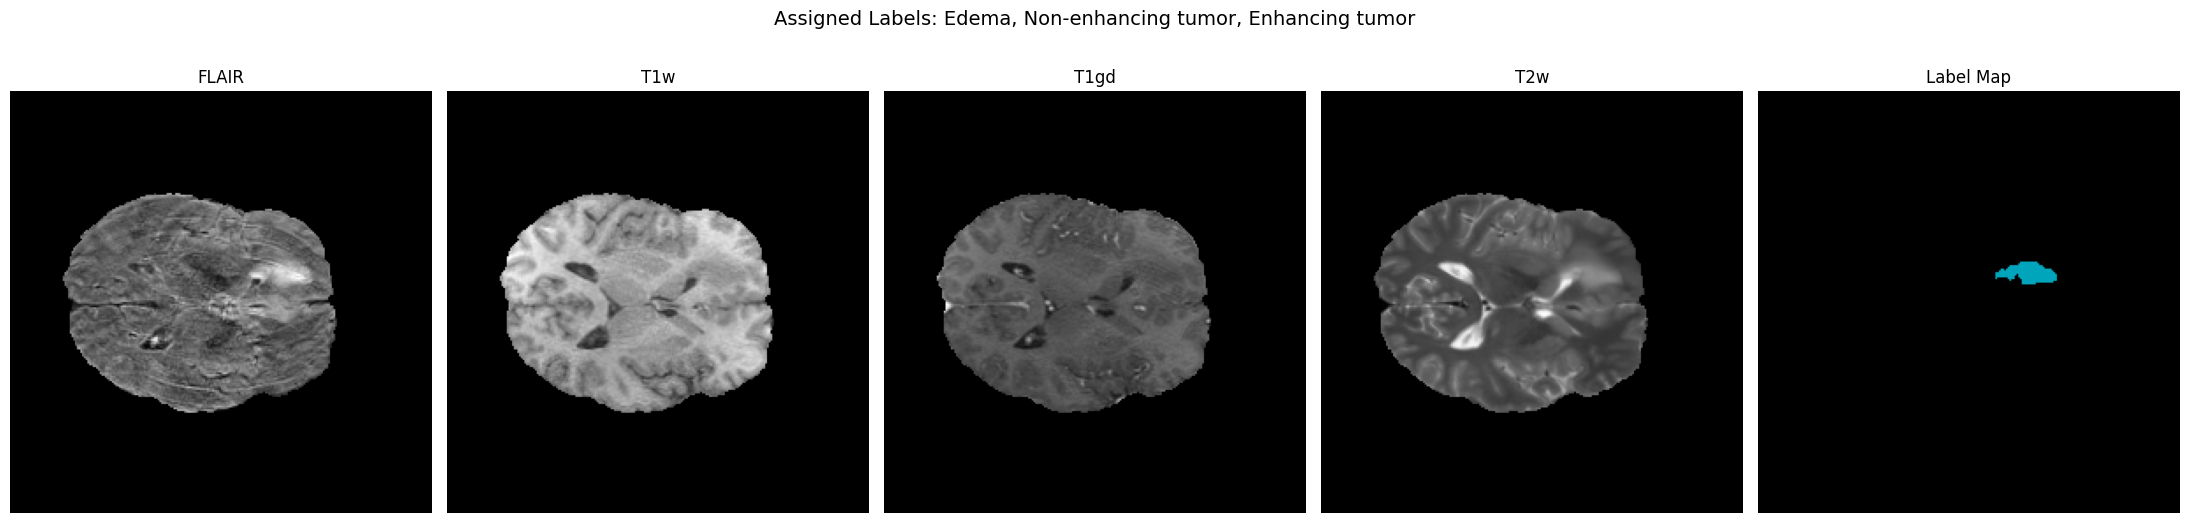


Visualizing: BRATS_058.nii.gz


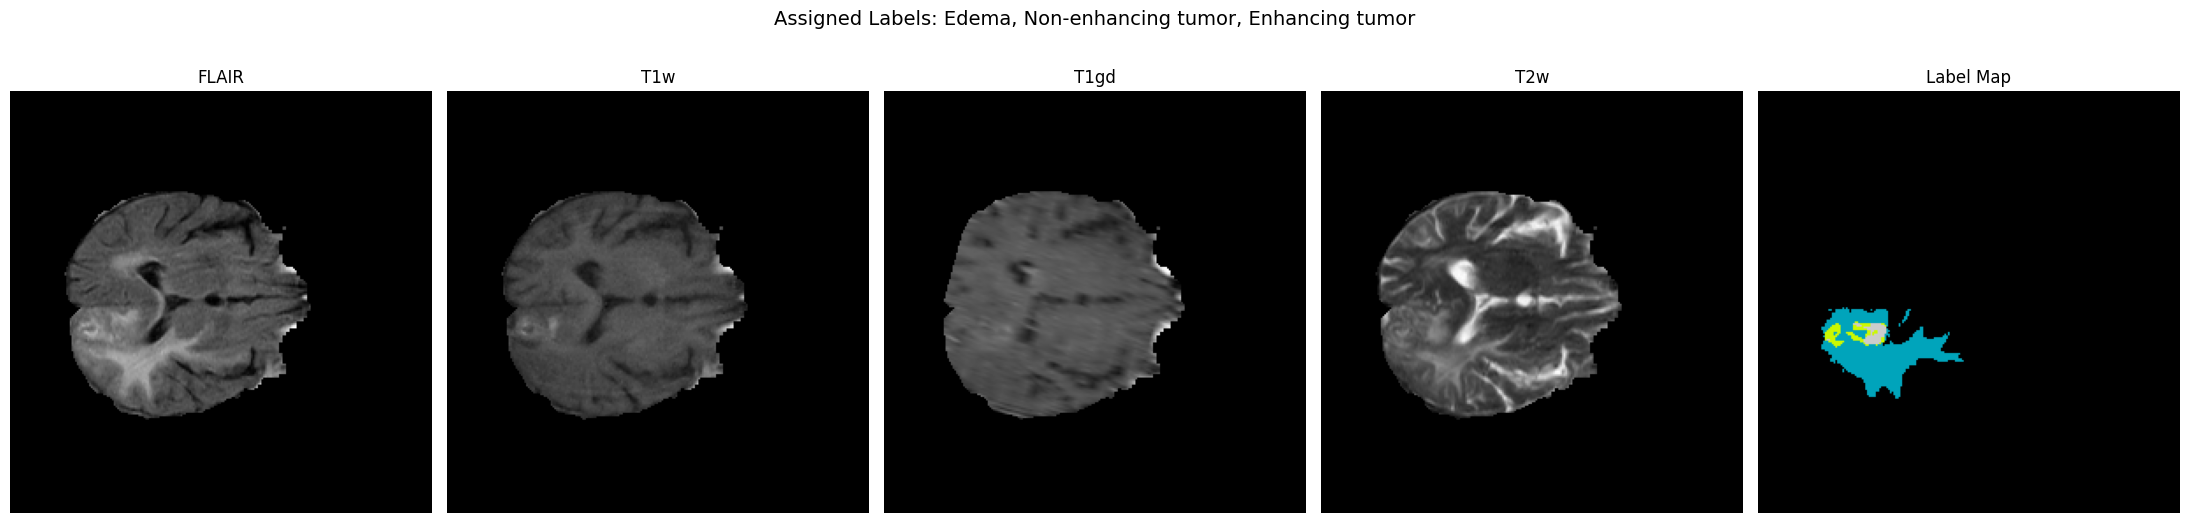


Visualizing: BRATS_013.nii.gz


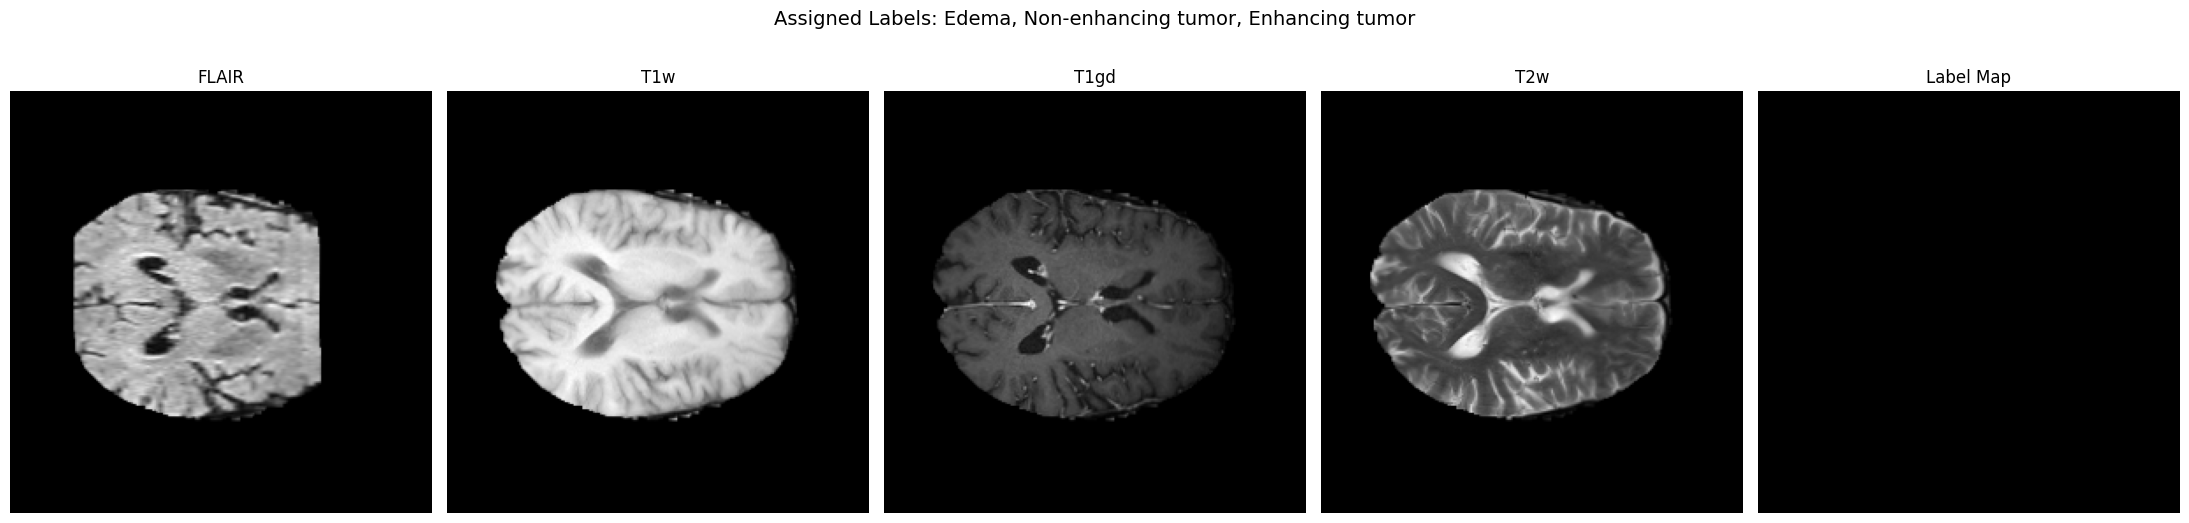

In [7]:
for img, lbl in zip(sample_images, sample_labels):
    print(f"\nVisualizing: {os.path.basename(img)}")
    plot_slices_with_labels(img, lbl)

In [8]:
import os
import nibabel as nib
import numpy as np
import torch
from torch.utils.data import Dataset
import random

In [9]:
def resize_to_256(image, mask):
    """
    Resize image and mask to 256x256 (required by SMP encoders)
    image: shape (1, H, W)
    mask: shape (H, W)
    """
    image_resized = cv2.resize(image[0], (256, 256), interpolation=cv2.INTER_LINEAR)
    mask_resized = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
    return np.expand_dims(image_resized, axis=0), mask_resized


In [10]:
class BRATSSliceDataset(Dataset):
    def __init__(self, image_label_pairs, modality_index=0, transform=None):
        self.slice_indices = []  # list of (image_path, label_path, slice_index)
        self.modality_index = modality_index
        self.transform = transform

        for pair in image_label_pairs:
            img_path = pair['image']
            label_path = pair['label']

            img_nii = nib.load(img_path)
            label_nii = nib.load(label_path)

            img_data = img_nii.get_fdata()[..., modality_index]
            label_data = label_nii.get_fdata()

            for i in range(img_data.shape[2]):
                if np.any(label_data[:, :, i] > 0):  # tumor exists in slice
                    self.slice_indices.append((img_path, label_path, i))

    def __len__(self):
        return len(self.slice_indices)

    def __getitem__(self, idx):
        img_path, label_path, slice_idx = self.slice_indices[idx]

        image = nib.load(img_path).get_fdata()[..., self.modality_index][:, :, slice_idx]
        mask = nib.load(label_path).get_fdata()[:, :, slice_idx]

        # Normalize image
        image = (image - np.mean(image)) / (np.std(image) + 1e-5)

        # Add channel dim
        image = np.expand_dims(image, axis=0)
        image, mask = resize_to_256(image, mask)
        if self.transform:
            image, mask = self.transform(image, mask)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)


In [11]:
import matplotlib.pyplot as plt
import random

def visualize_sample(dataset, num_samples=5):
    """Randomly visualize a few image slices and their masks"""
    indices = random.sample(range(len(dataset)), num_samples)
    
    for i, idx in enumerate(indices):
        image, mask = dataset[idx]
        image = image[0]  # remove channel dim

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Image Slice {idx}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(mask, cmap='nipy_spectral', interpolation='none')
        plt.title("Segmentation Mask")
        plt.axis('off')

        plt.tight_layout()
        plt.show()


In [12]:
import json
import os 
from pathlib import Path

def load_train_pairs(json_path, base_dir):
    with open(json_path) as f:
        data_info = json.load(f)

    pairs = data_info['training']
    
    full_pairs = []
    for p in pairs:
        full_image = os.path.join(base_dir, p['image'].lstrip("./"))
        full_label = os.path.join(base_dir, p['label'].lstrip("./"))
        full_pairs.append({'image': full_image, 'label': full_label})
    
    return full_pairs

# Example usage
dataset_base_dir = Path('../dataset').resolve()  # <-- replace this
train_pairs = load_train_pairs('../dataset/dataset.json', dataset_base_dir)

# Then load the dataset as before
dataset = BRATSSliceDataset(train_pairs, modality_index=0)

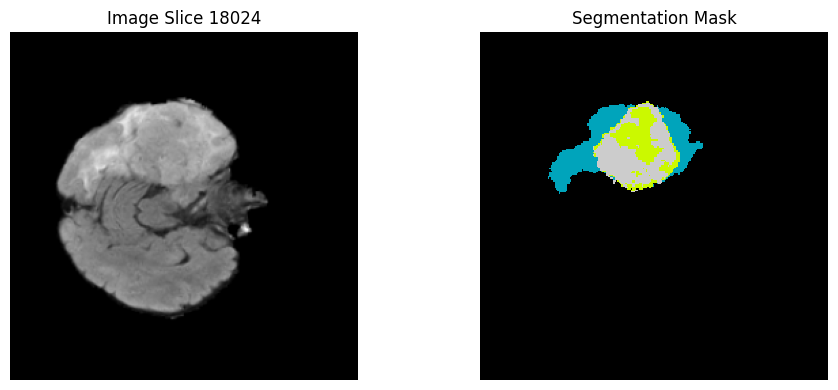

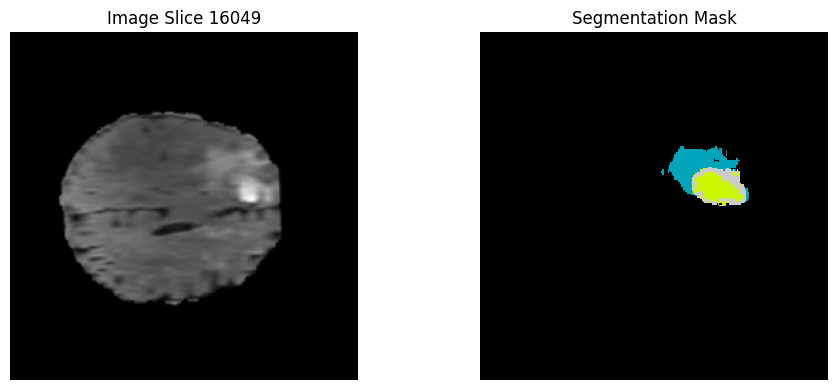

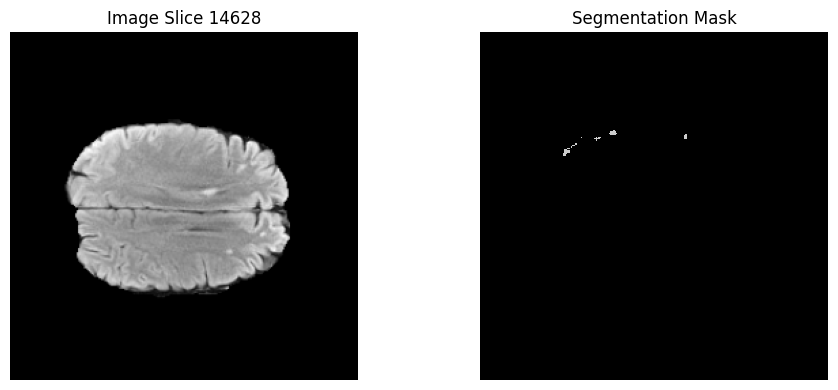

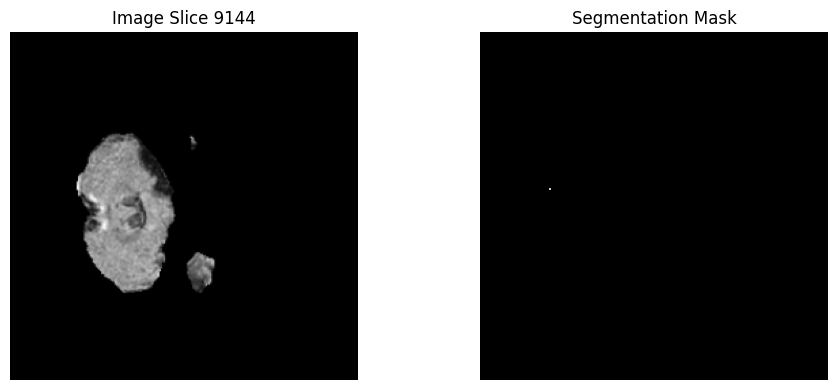

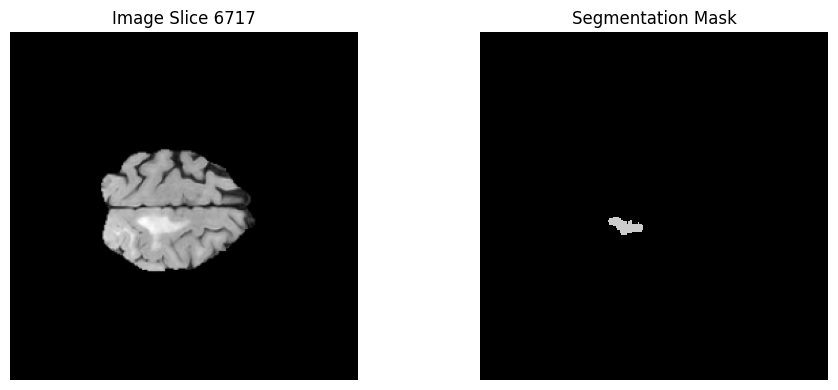

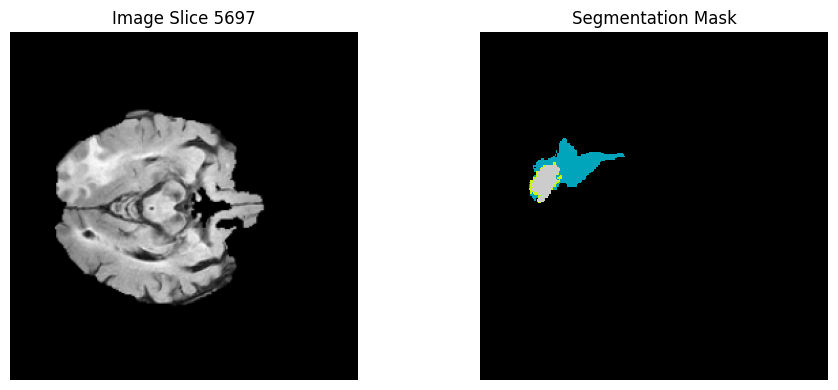

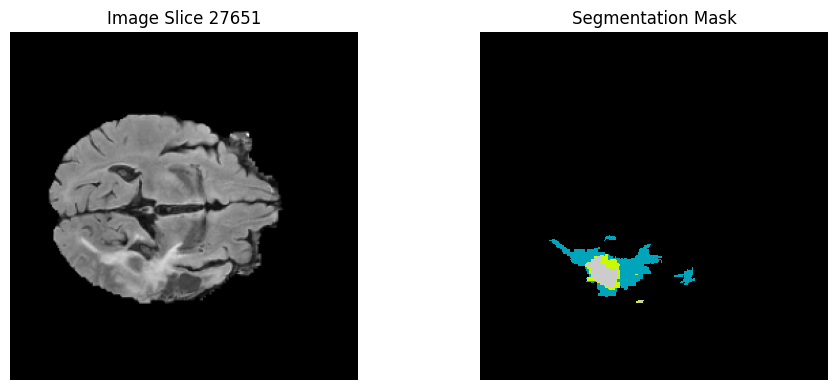

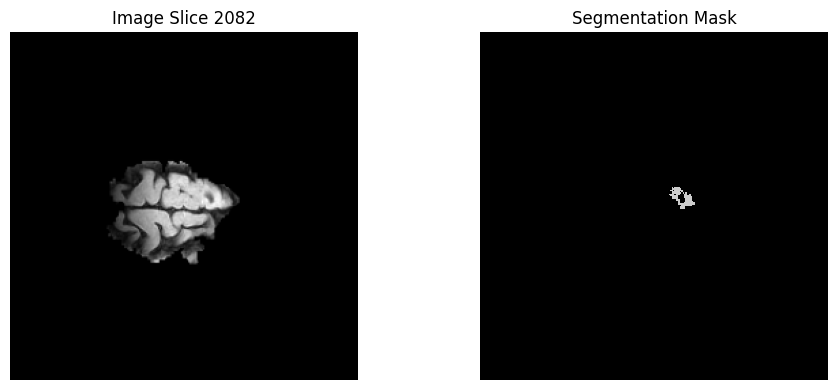

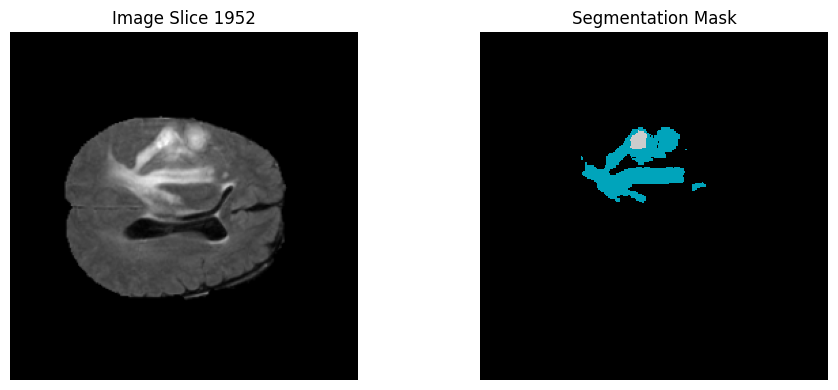

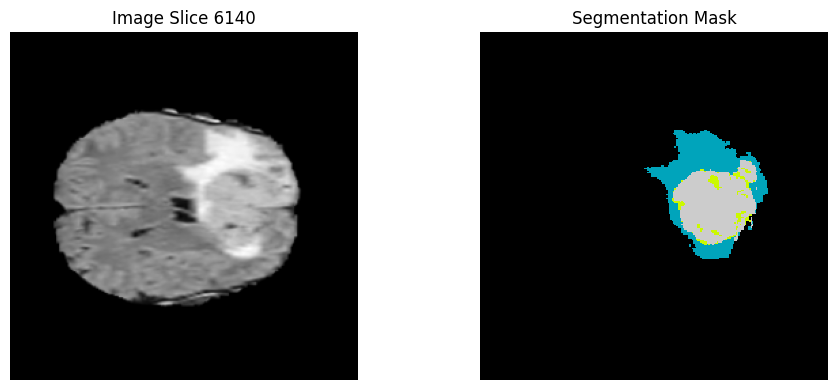

In [13]:
# Visualize
visualize_sample(dataset, num_samples=10)

In [14]:
def get_pretrained_unet(encoder='resnet34', encoder_weights='imagenet', in_channels=1, classes=4):
    model = smp.Unet(
        encoder_name=encoder,        # choose encoder: 'resnet34', 'resnet50', 'efficientnet-b0', etc.
        encoder_weights=encoder_weights,  # use 'imagenet' or None
        in_channels=in_channels,     # 1 for grayscale MRI
        classes=classes,             # number of segmentation classes
        activation=None              # we’ll use CrossEntropyLoss so no activation here
    )
    return model

In [15]:
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

def dice_score(preds, targets, num_classes=4):
    preds = torch.argmax(preds, dim=1)
    dice = []

    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        dice_cls = (2. * intersection + 1e-5) / (union + 1e-5)
        dice.append(dice_cls.item())
    
    return sum(dice) / len(dice)


In [16]:
def train_model(model, train_dataset, val_dataset=None, num_epochs=10, batch_size=8, lr=1e-3, device='cuda' if torch.cuda.is_available() else 'cpu'):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False) if val_dataset else None

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        train_dice = 0

        loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for images, masks in loop:
            images, masks = images.to(device), masks.to(device)

            preds = model(images)
            loss = criterion(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_dice += dice_score(preds, masks)

            loop.set_postfix(loss=loss.item())

        avg_loss = train_loss / len(train_loader)
        avg_dice = train_dice / len(train_loader)
        print(f'Epoch {epoch+1}: Loss={avg_loss:.4f}, Dice={avg_dice:.4f}')

        if val_loader:
            model.eval()
            val_dice = 0
            with torch.no_grad():
                for images, masks in val_loader:
                    images, masks = images.to(device), masks.to(device)
                    preds = model(images)
                    val_dice += dice_score(preds, masks)
            print(f'Validation Dice: {val_dice / len(val_loader):.4f}')


In [17]:
from sklearn.model_selection import train_test_split

# Load full training set
all_pairs = load_train_pairs('../dataset/dataset.json', dataset_base_dir)

# Split into train and validation (e.g., 80/20)
train_pairs, val_pairs = train_test_split(all_pairs, test_size=0.2, random_state=42)

# Create dataset objects
train_dataset = BRATSSliceDataset(train_pairs, modality_index=0)
val_dataset = BRATSSliceDataset(val_pairs, modality_index=0)

In [18]:
model = get_pretrained_unet(encoder='resnet34', encoder_weights='imagenet')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
train_model(model, train_dataset, val_dataset, num_epochs=10)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

C:\Users\Statia 1\miniconda3\envs\bratc\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Statia 1\.cache\huggingface\hub\models--smp-hub--resnet34.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Epoch 1/10: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3381/3381 [4:13:09<00:00,  4.49s/it, loss=0.0235]


Epoch 1: Loss=0.0451, Dice=0.5184
Validation Dice: 0.5964


...

Epoch 8: Loss=0.0140, Dice=0.8250
Validation Dice: 0.6723


Epoch 9/10: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3381/3381 [2:22:10<00:00,  2.52s/it, loss=0.0121]


Epoch 9: Loss=0.0133, Dice=0.8340
Validation Dice: 0.6747


Epoch 10/10: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3381/3381 [2:22:19<00:00,  2.53s/it, loss=0.00951]


Epoch 10: Loss=0.0128, Dice=0.8410
Validation Dice: 0.6764


In [19]:
def save_model(model, path):
    torch.save(model.state_dict(), path)
    print(f"✅ Model saved to: {path}")

In [21]:
save_model(model, 'models/unet2d_final.pth')

✅ Model saved to: models/unet2d_final.pth


In [1]:
def evaluate_model(model, test_dataset, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    total_dice = 0

    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="Evaluating"):
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            total_dice += dice_score(preds, masks)

    avg_dice = total_dice / len(val_loader)
    print(f'Validation Dice Score: {avg_dice:.4f}')


NameError: name 'torch' is not defined

In [23]:
import matplotlib.pyplot as plt

def visualize_predictions(model, val_dataset, num_samples=5, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    indices = random.sample(range(len(val_dataset)), num_samples)

    with torch.no_grad():
        for idx in indices:
            image, true_mask = val_dataset[idx]
            image = image.unsqueeze(0).to(device)
            pred_mask = model(image)
            pred_mask = torch.argmax(pred_mask, dim=1).squeeze(0).cpu().numpy()
            true_mask = true_mask.numpy()
            image = image.squeeze().cpu().numpy()

            plt.figure(figsize=(12, 4))
            plt.subplot(1, 3, 1)
            plt.imshow(image, cmap='gray')
            plt.title('Image')
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(true_mask, cmap='nipy_spectral')
            plt.title('Ground Truth')
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(pred_mask, cmap='nipy_spectral')
            plt.title('Prediction')
            plt.axis('off')
            plt.show()


Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6713/6713 [36:45<00:00,  3.04it/s]


🧪 Validation Dice Score: 0.6764


Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6713/6713 [38:16<00:00,  2.92it/s]



📊 Evaluation Results:
  Dice Class 0: 0.9974
  Dice Class 1: 0.6329
  Dice Class 2: 0.4708
  Dice Class 3: 0.6047
  Pixel Accuracy: 0.9900
  Confusion Matrix:
[[427869281    715731     79271     36985]
 [  1042702   5302632    199968    193601]
 [   171992    624007    902422    412226]
 [   133625    523123    283289   1452313]]


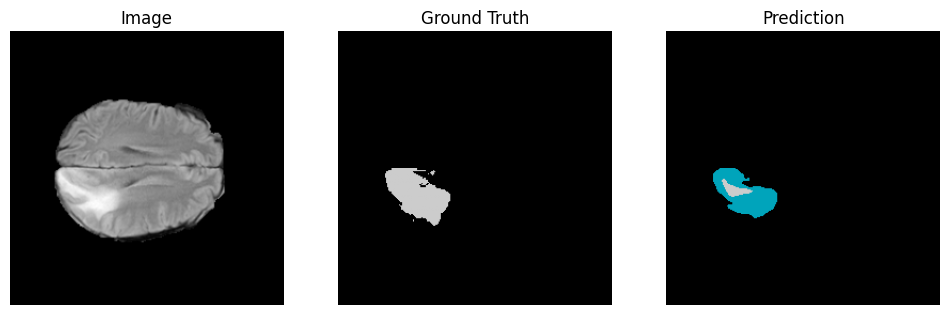

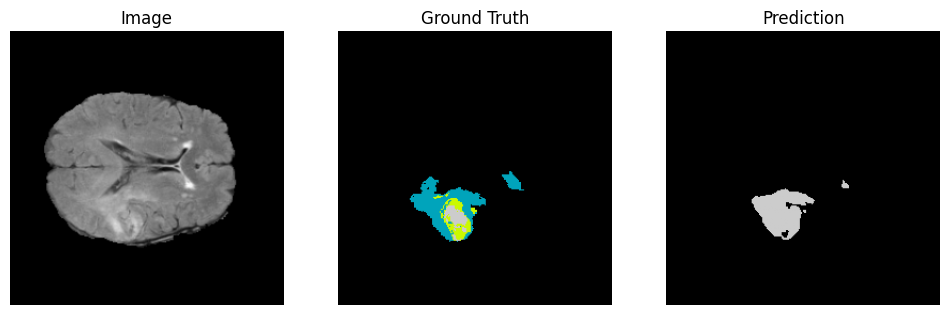

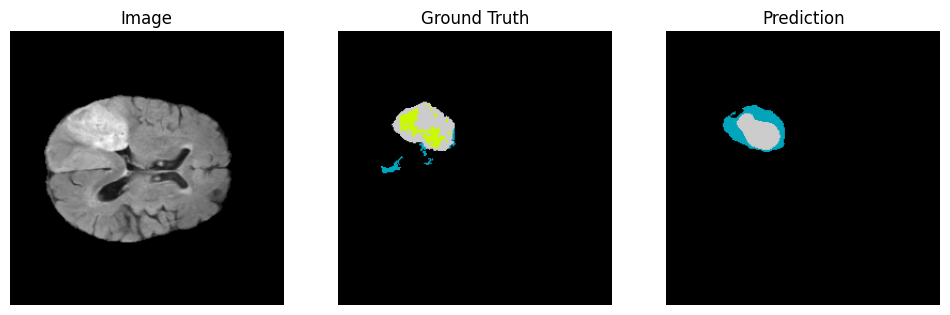

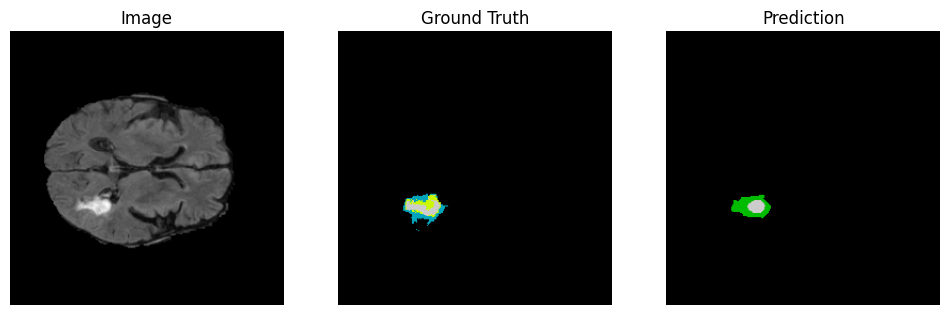

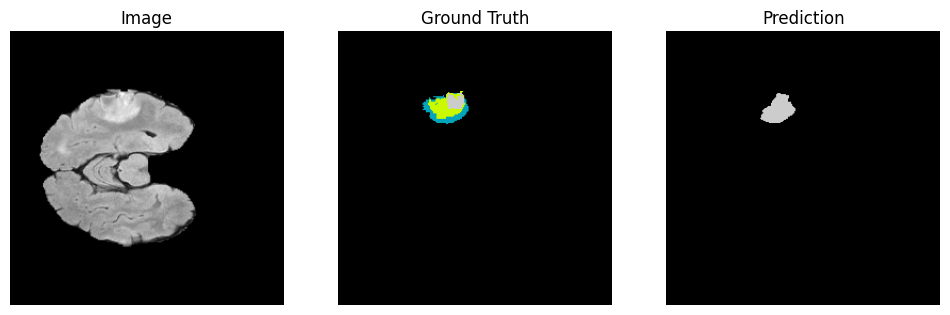

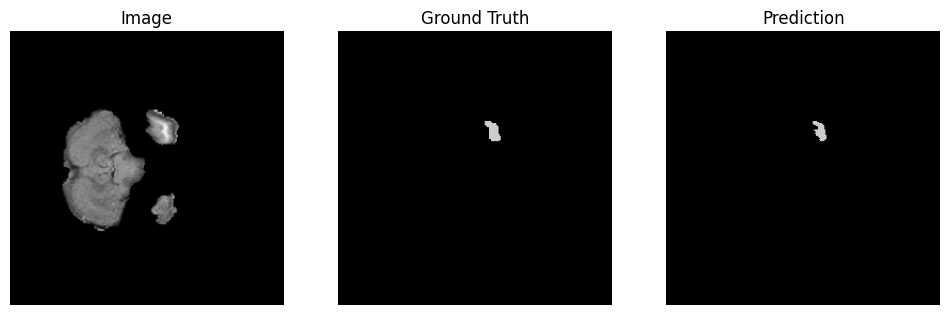

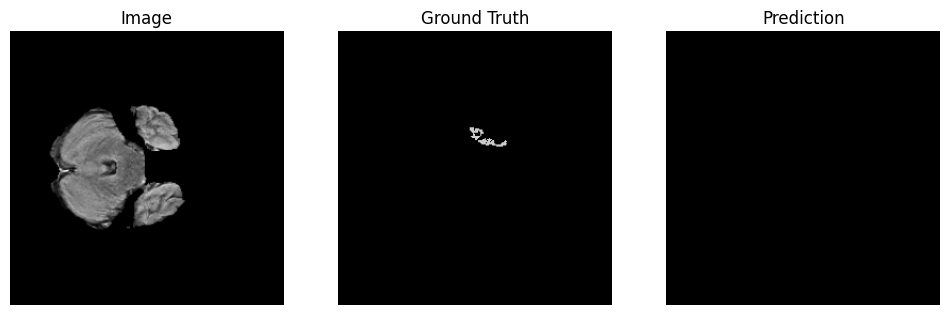

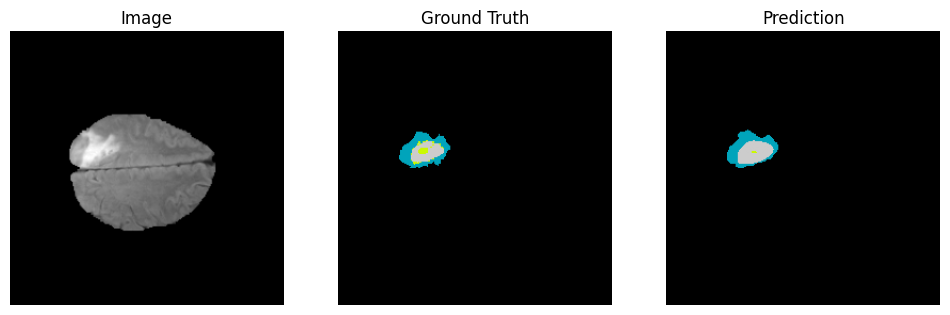

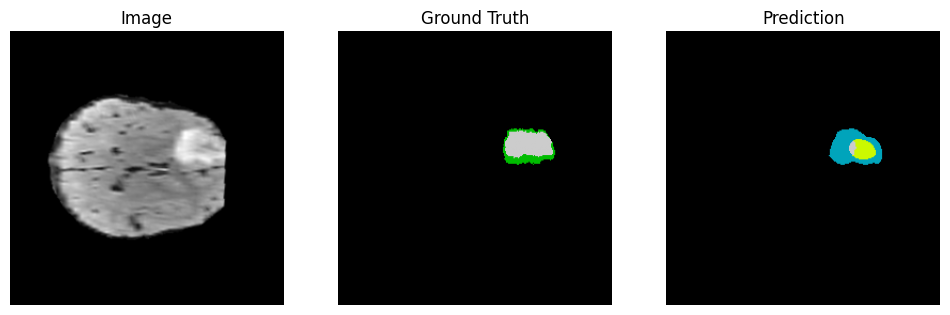

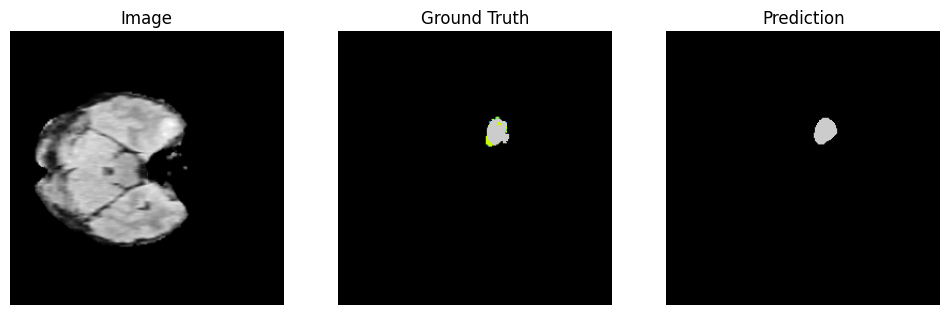

In [25]:
evaluate_model(model, val_dataset)
evaluate_metrics(model, val_dataset)
visualize_predictions(model, val_dataset, num_samples=10)


In [24]:
from sklearn.metrics import confusion_matrix
import numpy as np

def evaluate_metrics(model, dataset, num_classes=4, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    loader = DataLoader(dataset, batch_size=1, shuffle=False)
    
    dice_scores = np.zeros(num_classes)
    total_pixels = 0
    correct_pixels = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Evaluating"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            # Pixel accuracy
            correct_pixels += (preds == masks).sum().item()
            total_pixels += torch.numel(masks)

            # Dice score
            for cls in range(num_classes):
                pred_cls = (preds == cls).float()
                true_cls = (masks == cls).float()
                intersection = (pred_cls * true_cls).sum()
                union = pred_cls.sum() + true_cls.sum()
                dice = (2 * intersection + 1e-5) / (union + 1e-5)
                dice_scores[cls] += dice.item()

            # Confusion matrix
            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(masks.cpu().numpy().flatten())

    avg_dice = dice_scores / len(loader)
    accuracy = correct_pixels / total_pixels
    cm = confusion_matrix(all_targets, all_preds, labels=range(num_classes))

    print(f"\n📊 Evaluation Results:")
    for i, d in enumerate(avg_dice):
        print(f"  Dice Class {i}: {d:.4f}")
    print(f"  Pixel Accuracy: {accuracy:.4f}")
    print(f"  Confusion Matrix:\n{cm}")

    return avg_dice, accuracy, cm
